In [24]:
import pandas as pd
from process_pvgis import process_pvgis
PVGIS_filename = "../data/Timeseries_59.246_18.035_SA3_1kWp_crystSi_14_42deg_0deg_2022_2023.csv"

X_train, X_test, y_train, y_test = process_pvgis(PVGIS_filename)

In [25]:
y_train = y_train.values.ravel()

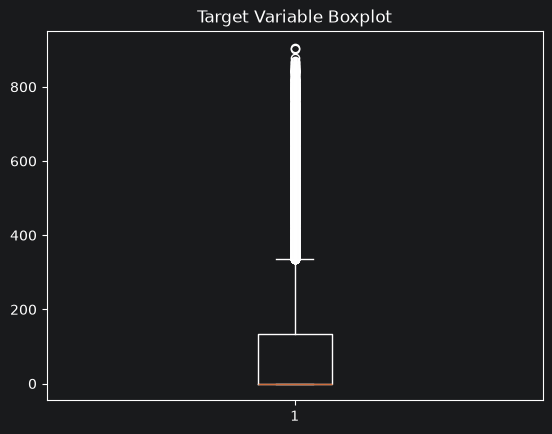

In [26]:
import matplotlib.pyplot as plt
plt.boxplot(y_train)
plt.title("Target Variable Boxplot")
plt.show()

In [27]:
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(y_train))
outliers = y_train[z_scores > 3]
print(f"Outliers (Z-score > 3): {len(outliers)}")
print(round(len(outliers)/len(y_train)*100, 2), "% Outliers")

Outliers (Z-score > 3): 165
1.88 % Outliers


In [28]:
Q1 = np.percentile(y_train, 25)
Q3 = np.percentile(y_train, 75)
IQR = Q3 - Q1
outliers = y_train[(y_train < Q1 - 1.5 * IQR) | (y_train > Q3 + 1.5 * IQR)]
print(f"Outliers (IQR method): {len(outliers)}")

Outliers (IQR method): 1370


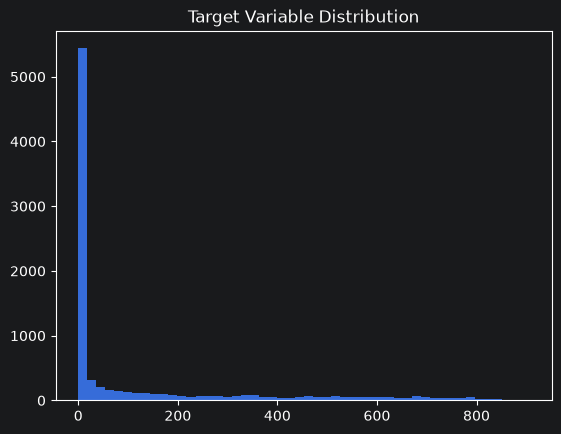

In [29]:
import matplotlib.pyplot as plt
plt.hist(y_train, bins=50)
plt.title("Target Variable Distribution")
plt.show()

In [32]:
from scipy import stats
print(f"Skewness: {stats.skew(y_train):.2f}")  # >0 = right-skewed, <0 = left-skewed
print(f"Kurtosis: {stats.kurtosis(y_train):.2f}")  # >0 = heavy-tailed, <0 = light-tailed

Skewness: 1.84
Kurtosis: 2.23


In [33]:
print("The minimum value is:", min(y_train))
print("The maximum value is:", max(y_train))
print("The mean value is:", np.mean(y_train))
print("The median value is:", np.median(y_train))
print("The standard deviation is:", np.std(y_train))

The minimum value is: 0.0
The maximum value is: 905.79
The mean value is: 118.32235844748858
The median value is: 0.0
The standard deviation is: 212.27641962626564


In [35]:
best_model_mae = 1.4335245197470854
print("MAE is:", best_model_mae/np.mean(y_train)*100, "% of mean value")

MAE is: 1.2115415366600244 % of mean value
